## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
from fuzzywuzzy import fuzz
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_ID = 'EL52'

In [3]:
dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2009_2023.csv", encoding = enc)
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2009-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.024023,-2.005545,1.509239,5.166060,NaN,NaN,NaN,0.057874,NaN,NaN,NaN,2.696421,NaN,NaN,NaN,7.182207,47.966593,149.890159,213.071312,222.648418,617.518519,19.919952,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.0,1.0,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,-11.190000,12.110000,222.648418,0,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,11723.0,44888.0,13557.0,70168.0,11361.0,44491.0,16024.0,71876.0,2098.63,NaN,NaN
1,2009-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,2009,0.168991,0.328042,0.189503,-0.328042,0.151776,0.329784,0.194638,-0.329784,0.044706,0.092952,0.120742,0.092952,7.062771,-0.527071,3.315124,7.145869,NaN,NaN,NaN,-0.061709,NaN,NaN,NaN,3.542080,NaN,NaN,NaN,7.153071,45.480772,149.749540,219.994285,221.745214,337.828125,10.897681,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.0,1.0,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,30,30,10,10,1,6,6,2,-5.581294,12.866563,221.745214,0,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,87281.0,374669.0,80103.0,542053.0,83839.0,403005.0,104992.0,591836.0,21520.33,NaN,NaN
2,2009-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,2009,0.218688,0.054729,-0.151006,-0.054729,0.213303,0.057652,-0.139077,-0.057652,0.041294,0.052580,0.070135,0.052580,7.286387,-2.417355,2.488471,7.289129,NaN,NaN,NaN,-1.712222,NaN,NaN,NaN,2.788454,NaN,NaN,NaN,7.194280,48.061819,151.273150,221.102476,223.022679,310.630435,10.020337,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.0,1.0,22771.829003,3753.170334,32,324.927224,972.921816,192.844282,0.024394,600.402036,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,31,36,30,12,12,3,5,8,2,-8.991429,

<AxesSubplot:>

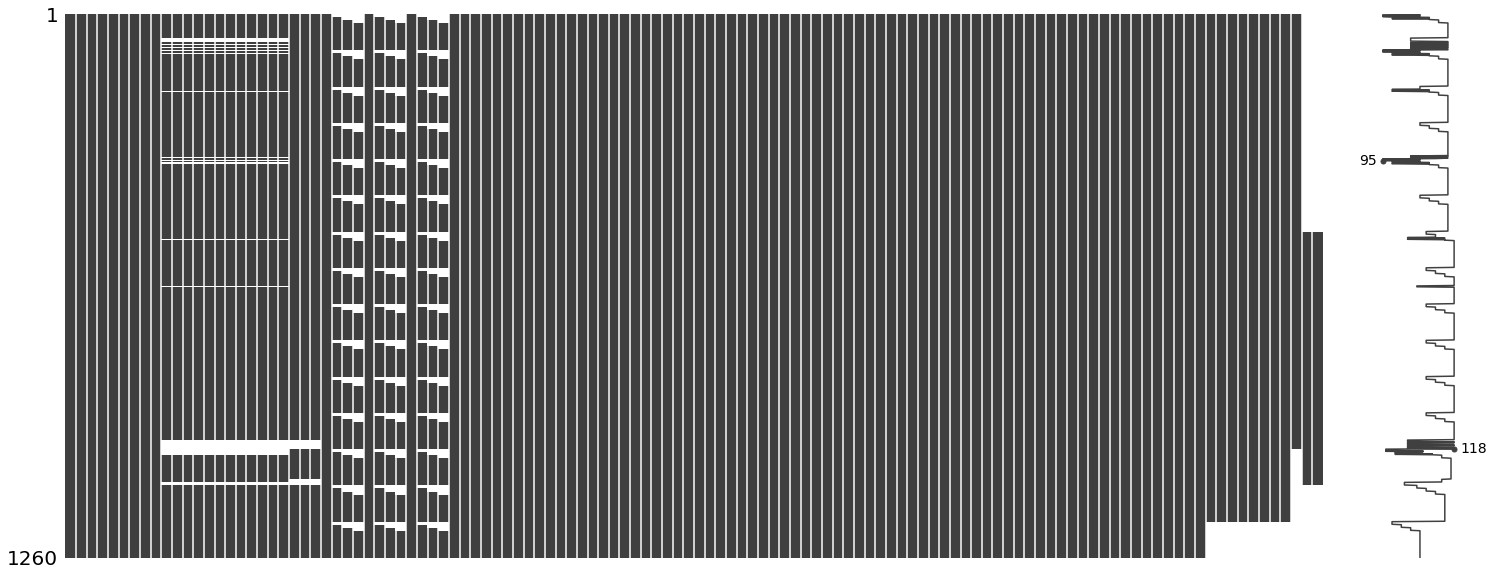

In [4]:
missingno.matrix(dataset_monthly)

In [5]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
0,ndvi,6.0317
1,ndmi,6.0317
2,ndwi,6.0317
3,ndbi,6.0317
4,ndvi_mean,5.9524
...,...,...
30,F_Y_GE65,6.6667
31,F_TOTAL,6.6667
32,MIO_EUR,20.0000
33,L_TOTAL,53.3333


In [6]:
years = dataset_monthly.year.unique()
nuts3_units = dataset_monthly.NUTS3_NAME.unique()

In [7]:
data = []

for year in years:
    for region in nuts3_units:
        filtered_df = dataset_monthly.loc[(dataset_monthly['year'] == year) & (dataset_monthly['NUTS3_NAME'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        q1_df = filtered_df.loc[(filtered_df['month'] <= 3)]
        q2_df = filtered_df.loc[(filtered_df['month'] <= 6)]
        q3_df = filtered_df.loc[(filtered_df['month'] <= 9)]
        q4_df = filtered_df.loc[(filtered_df['month'] <= 12)]

        min_temp_q1 = q1_df['lst_mean'].min()
        mean_temp_q1 = q1_df['lst_mean'].mean()
        max_temp_q1 = q1_df['lst_mean'].max()
        prec_q1 = q1_df['rainfall_mean'].sum()

        ndvi_q1 = q1_df['ndvi'].mean()
        ndwi_q1 = q1_df['ndwi'].mean()
        ndmi_q1 = q1_df['ndmi'].mean()
        ndbi_q1 = q1_df['ndbi'].mean()

        ndvi_mean_q1 = q1_df['ndvi_mean'].mean()
        ndwi_mean_q1 = q1_df['ndwi_mean'].mean()
        ndmi_mean_q1 = q1_df['ndmi_mean'].mean()
        ndbi_mean_q1 = q1_df['ndbi_mean'].mean()

        ndvi_std_q1 = q1_df['ndvi_std'].mean()
        ndwi_std_q1 = q1_df['ndwi_std'].mean()
        ndmi_std_q1 = q1_df['ndmi_std'].mean()
        ndbi_std_q1 = q1_df['ndbi_std'].mean()

        min_temp_q2 = q2_df['lst_mean'].min()
        mean_temp_q2 = q2_df['lst_mean'].mean()
        max_temp_q2 = q2_df['lst_mean'].max()
        prec_q2 = q2_df['rainfall_mean'].sum()

        ndvi_q2 = q2_df['ndvi'].mean()
        ndwi_q2 = q2_df['ndwi'].mean()
        ndmi_q2 = q2_df['ndmi'].mean()
        ndbi_q2 = q2_df['ndbi'].mean()

        ndvi_mean_q2 = q2_df['ndvi_mean'].mean()
        ndwi_mean_q2 = q2_df['ndwi_mean'].mean()
        ndmi_mean_q2 = q2_df['ndmi_mean'].mean()
        ndbi_mean_q2 = q2_df['ndbi_mean'].mean()

        ndvi_std_q2 = q2_df['ndvi_std'].mean()
        ndwi_std_q2 = q2_df['ndwi_std'].mean()
        ndmi_std_q2 = q2_df['ndmi_std'].mean()
        ndbi_std_q2 = q2_df['ndbi_std'].mean()

        min_temp_q3 = q3_df['lst_mean'].min()
        mean_temp_q3 = q3_df['lst_mean'].mean()
        max_temp_q3 = q3_df['lst_mean'].max()
        prec_q3 = q3_df['rainfall_mean'].sum()

        ndvi_q3 = q3_df['ndvi'].mean()
        ndwi_q3 = q3_df['ndwi'].mean()
        ndmi_q3 = q3_df['ndmi'].mean()
        ndbi_q3 = q3_df['ndbi'].mean()

        ndvi_mean_q3 = q3_df['ndvi_mean'].mean()
        ndwi_mean_q3 = q3_df['ndwi_mean'].mean()
        ndmi_mean_q3 = q3_df['ndmi_mean'].mean()
        ndbi_mean_q3 = q3_df['ndbi_mean'].mean()

        ndvi_std_q3 = q3_df['ndvi_std'].mean()
        ndwi_std_q3 = q3_df['ndwi_std'].mean()
        ndmi_std_q3 = q3_df['ndmi_std'].mean()
        ndbi_std_q3 = q3_df['ndbi_std'].mean()

        min_temp_q4 = q4_df['lst_mean'].min()
        mean_temp_q4 = q4_df['lst_mean'].mean()
        max_temp_q4 = q4_df['lst_mean'].max()
        prec_q4 = q4_df['rainfall_mean'].sum()

        ndvi_q4 = q4_df['ndvi'].mean()
        ndwi_q4 = q4_df['ndwi'].mean()
        ndmi_q4 = q4_df['ndmi'].mean()
        ndbi_q4 = q4_df['ndbi'].mean()

        ndvi_mean_q4 = q4_df['ndvi_mean'].mean()
        ndwi_mean_q4 = q4_df['ndwi_mean'].mean()
        ndmi_mean_q4 = q4_df['ndmi_mean'].mean()
        ndbi_mean_q4 = q4_df['ndbi_mean'].mean()

        ndvi_std_q4 = q4_df['ndvi_std'].mean()
        ndwi_std_q4 = q4_df['ndwi_std'].mean()
        ndmi_std_q4 = q4_df['ndmi_std'].mean()
        ndbi_std_q4 = q4_df['ndbi_std'].mean()

        data.append({'NUTS3_NAME': region, 
                     'year': year, 
                     'min_temp_q1': min_temp_q1,
                     'mean_temp_q1': mean_temp_q1,
                     'max_temp_q1': max_temp_q1,
                     'prec_q1': prec_q1,
                     'ndvi_q1': ndvi_q1,
                     'ndwi_q1': ndwi_q1,
                     'ndmi_q1': ndmi_q1,
                     'ndbi_q1': ndbi_q1,
                     'ndvi_mean_q1': ndvi_mean_q1,
                     'ndwi_mean_q1': ndwi_mean_q1,
                     'ndmi_mean_q1': ndmi_mean_q1,
                     'ndbi_mean_q1': ndbi_mean_q1,
                     'ndvi_std_q1': ndvi_std_q1,
                     'ndwi_std_q1': ndwi_std_q1,
                     'ndmi_std_q1': ndmi_std_q1,
                     'ndbi_std_q1': ndbi_std_q1,
                     'min_temp_q2': min_temp_q2,
                     'mean_temp_q2': mean_temp_q2,
                     'max_temp_q2': max_temp_q2,
                     'prec_q2': prec_q2,
                     'ndvi_q2': ndvi_q2,
                     'ndwi_q2': ndwi_q2,
                     'ndmi_q2': ndmi_q2,
                     'ndbi_q2': ndbi_q2,
                     'ndvi_mean_q2': ndvi_mean_q2,
                     'ndwi_mean_q2': ndwi_mean_q2,
                     'ndmi_mean_q2': ndmi_mean_q2,
                     'ndbi_mean_q2': ndbi_mean_q2,
                     'ndvi_std_q2': ndvi_std_q2,
                     'ndwi_std_q2': ndwi_std_q2,
                     'ndmi_std_q2': ndmi_std_q2,
                     'ndbi_std_q2': ndbi_std_q2,
                     'min_temp_q3': min_temp_q3,
                     'mean_temp_q3': mean_temp_q3,
                     'max_temp_q3': max_temp_q3,
                     'prec_q3': prec_q3,
                     'ndvi_q3': ndvi_q3,
                     'ndwi_q3': ndwi_q3,
                     'ndmi_q3': ndmi_q3,
                     'ndbi_q3': ndbi_q3,
                     'ndvi_mean_q3': ndvi_mean_q3,
                     'ndwi_mean_q3': ndwi_mean_q3,
                     'ndmi_mean_q3': ndmi_mean_q3,
                     'ndbi_mean_q3': ndbi_mean_q3,
                     'ndvi_std_q3': ndvi_std_q3,
                     'ndwi_std_q3': ndwi_std_q3,
                     'ndmi_std_q3': ndmi_std_q3,
                     'ndbi_std_q3': ndbi_std_q3,
                     'min_temp_q4': min_temp_q4,
                     'mean_temp_q4': mean_temp_q4,
                     'max_temp_q4': max_temp_q4,
                     'prec_q4': prec_q4,
                     'ndvi_q4': ndvi_q4,
                     'ndwi_q4': ndwi_q4,
                     'ndmi_q4': ndmi_q4,
                     'ndbi_q4': ndbi_q4,
                     'ndvi_mean_q4': ndvi_mean_q4,
                     'ndwi_mean_q4': ndwi_mean_q4,
                     'ndmi_mean_q4': ndmi_mean_q4,
                     'ndbi_mean_q4': ndbi_mean_q4,
                     'ndvi_std_q4': ndvi_std_q4,
                     'ndwi_std_q4': ndwi_std_q4,
                     'ndmi_std_q4': ndmi_std_q4,
                     'ndbi_std_q4': ndbi_std_q4})
        
q_df = pd.DataFrame(data)        

In [8]:
q_df

,NUTS3_NAME,year,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,ημαθια,2009,1.509239,4.663823,7.643042,11.756611,0.338261,-0.236155,0.083967,-0.083967,0.329395,-0.239247,0.075621,-0.075621,0.053953,0.049460,0.053392,0.053392,1.509239,11.989997,23.159531,21.159051,0.396796,-0.238179,0.137084,-0.137084,0.392284,-0.232939,0.138621,-0.138621,0.047894,0.038397,0.046202,0.046202,1.509239,15.889353,24.851703,27.540381,0.448778,-0.258939,0.166486,-0.166486,0.444230,-0.251853,0.168831,-0.168831,0.051398,0.036570,0.050371,0.050371,1.509239,14.514162,24.851703,47.766417,0.448778,-0.258939,0.166486,-0.166486,0.444230,-0.251853,0.168831,-0.168831,0.051398,0.036570,0.050371,0.050371
1,θεσσαλονικη,2009,3.315124,5.611375,8.536321,11.463950,0.286499,-0.131483,0.132514,-0.132514,0.277792,-0.126993,0.133498,-0.133498,0.051509,0.080823,0.068438,0.068438,3.315124,12.970490,25.255302,20.049011,0.343287,-0.202762,0.124417,-0.124417,0.336483,-0.196093,0.125890,-0.125890,0.054863,0.066160,0.061764,0.061764,3.315124,17.195478,27.080930,27.955199,0.355338,-0.225071,0.115687,-0.115687,0.349348,-0.215786,0.119642,-0.119642,0.056906,0.061969,0.062152,0.062152,3.315124,15.831436,27.080930,43.403122,0.342978,-0.227463,0.096967,-0.096967,0.335772,-0.216286,0.101591,-0.101591,0.056806,0.064433,0.063206,0.063206
2,κιλκις,2009,2.488471,5.236699,8.492451,11.785239,0.258617,-0.233215,0.023010,-0.023010,0.255981,-0.224425,0.026558,-0.026558,0.042597,0.056653,0.049318,0.049318,2.488471,12.695879,25.400207,21.175494,0.339122,-0.280441,0.056799,-0.056799,0.337901,-0.274241,0.061306,-0.061306,0.044445,0.042495,0.047462,0.047462,2.488471,17.160239,27.739600,28.366552,0.347872,-0.295720,0.051166,-0.051166,0.343466,-0.287437,0.054977,-0.054977,0.047125,0.039960,0.049918,0.049918,2.488471,15.561839,27.739600,45.231496,0.326918,-0.273975,0.046078,-0.046078,0.323975,-0.267103,0.049524,-0.049524,0.043559,0.044636,0.047056,0.047056
3,πελλα,2009,2.135979,4.785755,7.647995,12.275012,0.196717,0.103282,0.271531,-0.271531,0.200897,0.117728,0.283083,-0.283083,0.040629,0.072319,0.054825,0.054825,2.135979,11.802102,22.933818,22.638545,0.312434,-0.087388,0.201689,-0.201689,0.309918,-0.072336,0.210880,-0.210880,0.040639,0.053855,0.047294,0.047294,2.135979,15.836104,25.443875,29.350555,0.366431,-0.141521,0.200016,-0.200016,0.362024,-0.125672,0.208825,-0.208825,0.044091,0.050809,0.048973,0.048973,2.135979,14.482714,25.443875,49.628073,0.342876,-0.126551,0.187698,-0.187698,0.340109,-0.117108,0.193125,-0.193125,0.040587,0.049193,0.044336,0.044336
4,πιερια,2009,3.157515,5.525360,8.051462,11.307251,0.380631,-0.281028,0.082936,-0.082936,0.368003,-0.276384,0.076174,-0.076174,0.056094,0.046381,0.055458,0.055458,3.157515,12.207188,23.683822,18.034787,0.418171,-0.265958,0.130951,-0.130951,0.411437,-0.258534,0.130376,-0.130376,0.053593,0.037415,0.052048,0.052048,3.157515,16.524356,26.598530,23.833780,0.426810,-0.281258,0.128122,-0.128122,0.422067,-0.272530,0.130132,-0.130132,0.056859,0.036104,0.055590,0.055590,3.157515,15.250158,26.598530,41.804314,0.426810,-0.281258,0.128122,-0.128122,0.422067,-0.272530,0.130132,-0.130132,0.056859,0.036104,0.055590,0.055590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [9]:
dataset_monthly = pd.merge(dataset_monthly, q_df,  how='left', on=['NUTS3_NAME', 'year'])

In [10]:
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2009-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.024023,-2.005545,1.509239,5.166060,NaN,NaN,NaN,0.057874,NaN,NaN,NaN,2.696421,NaN,NaN,NaN,7.182207,47.966593,149.890159,213.071312,222.648418,617.518519,19.919952,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.0,1.0,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,-11.190000,12.110000,222.648418,0,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,11723.0,44888.0,13557.0,70168.0,11361.0,44491.0,16024.0,71876.0,2098.63,NaN,NaN,1.509239,4.663823,7.643042,11.756611,0.338261,-0.236155,0.083967,-0.083967,0.329395,-0.239247,0.075621,-0.075621,0.053953,0.049460,0.053392,0.053392,1.509239,11.989997,23.159531,21.159051,0.396796,-0.238179,0.137084,-0.137084,0.392284,-0.232939,0.138621,-0.138621,0.047894,0.038397,0.046202,0.046202,1.509239,15.889353,24.851703,27.540381,0.448778,-0.258939,0.166486,-0.166486,0.444230,-0.251853,0.168831,-0.168831,0.051398,0.036570,0.050371,0.050371,1.509239,14.514162,24.851703,47.766417,0.448778,-0.258939,0.166486,-0.166486,0.444230,-0.251853,0.168831,-0.168831,0.051398,0.036570,0.050371,0.050371
1,2009-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,2009,0.168991,0.328042,0.189503,-0.328042,0.151776,0.329784,0.194638,-0.329784,0.044706,0.092952,0.120742,0.092952,7.062771,-0.527071,3.315124,7.145869,NaN,NaN,NaN,-0.061709,NaN,NaN,NaN,3.542080,NaN,NaN,NaN,7.153071,45.480772,149.749540,219.994285,221.745214,

In [11]:
grouped_annualy = dataset_monthly.groupby(['year', 'NUTS2_ID',	'NUTS2_NAME',	'NUTS3_ID',	'NUTS3_NAME'], as_index = False)
dataset_annual = grouped_annualy.mean()
dataset_annual.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2009,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,6.5,0.448778,0.166486,-0.258939,-0.166486,0.444230,0.168831,-0.251853,-0.168831,0.051398,0.050371,0.036570,0.050371,20.019486,9.008837,14.514162,5.166060,9.054669,14.068100,14.964794,0.057874,0.608776,1.209346,1.830765,2.696421,4.831723,7.638723,8.397780,3.980535,21.635065,60.370251,119.752964,702.611191,562.026235,18.450354,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0.0,53.475540,2.926239,142.953571,0.0,1.0,22226.661302,3839.763398,39.0,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,4.675859,24.656049,121.820123,0.0,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,11723.0,44888.0,13557.0,70168.0,11361.0,44491.0,16024.0,71876.0,2098.63,NaN,NaN,1.509239,4.663823,7.643042,11.756611,0.338261,-0.236155,0.083967,-0.083967,0.329395,-0.239247,0.075621,-0.075621,0.053953,0.049460,0.053392,0.053392,1.509239,11.989997,23.159531,21.159051,0.396796,-0.238179,0.137084,-0.137084,0.392284,-0.232939,0.138621,-0.138621,0.047894,0.038397,0.046202,0.046202,1.509239,15.889353,24.851703,27.540381,0.448778,-0.258939,0.166486,-0.166486,0.444230,-0.251853,0.168831,-0.168831,0.051398,0.036570,0.050371,0.050371,1.509239,14.514162,24.851703,47.766417,0.448778,-0.258939,0.166486,-0.166486,0.444230,-0.251853,0.168831,-0.168831,0.051398,0.036570,0.050371,0.050371
1,2009,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,6.5,0.342978,0.096967,-0.227463,-0.096967,0.335772,0.101591,-0.216286,-0.101591,0.056806,0.063206,0.064433,0.063206,22.169983,9.485009,15.831436,7.145

In [12]:
grouped_annualy_cases = dataset_monthly.groupby(['year', 'NUTS2_ID',	'NUTS2_NAME',	'NUTS3_ID',	'NUTS3_NAME'], as_index = False)
dataset_annual_cases = grouped_annualy_cases.sum()
dataset_annual_cases.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2009,EL52,κεντρικη μακεδονια,EL521,ημαθια,266.615436,486.625336,78,2.692669,0.998914,-1.553634,-0.998914,2.665378,1.012986,-1.511118,-1.012986,0.308389,0.302226,0.219421,0.302226,240.233837,108.106040,174.169938,61.992714,99.601362,140.681004,134.683149,0.694488,6.696541,12.093464,16.476883,32.357056,53.148952,76.387234,75.580016,47.766417,259.620779,724.443006,1437.035572,8431.334290,6744.314815,221.404250,150479.320940,17317.583898,112.666667,1805.045204,5358.827579,2082.748660,0.013645,374.238018,5171.432170,1099.718660,0,641.706479,35.114867,1715.442854,0.0,12.0,266719.935629,46077.160777,468,3543.322411,21461.258879,2532.608115,0.736853,12973.152822,74098.841365,11781.162243,111.805086,678.411610,6382.846832,158.242151,0.100273,1778.995708,372,432,360,144,144,12,72,84,24,56.110307,295.872593,1461.841477,0,172.0,236.0,491.666667,9985.443952,444.0,-132.0,576.0,66.0,282.0,288.0,50.0,17460.0,3552.0,540.0,754.896174,7968.0,2328.0,3108.0,6912.0,140676.0,538656.0,162684.0,842016.0,136332.0,533892.0,192288.0,862512.0,25183.56,0.0,0.0,18.110871,55.965881,91.716500,141.079336,4.059137,-2.833858,1.007609,-1.007609,3.952742,-2.870968,0.907454,-0.907454,0.647437,0.593522,0.640708,0.640708,18.110871,143.879959,277.914370,253.908614,4.761553,-2.858150,1.645010,-1.645010,4.707410,-2.795273,1.663452,-1.663452,0.574727,0.460766,0.554426,0.554426,18.110871,190.672239,298.220430,330.484573,5.385339,-3.107268,1.997827,-1.997827,5.330755,-3.022236,2.025972,-2.025972,0.616778,0.438843,0.604452,0.604452,18.110871,174.169938,298.220430,573.197010,5.385339,-3.107268,1.997827,-1.997827,5.330755,-3.022236,2.025972,-2.025972,0.616778,0.438843,0.604452,0.604452
1,2009,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,277.668399,488.323581,78,3.772758,1.066642,-2.502097,-1.066642,3.693488,1.117505,-2.379144,-1.117505,0.624870,0.695

In [13]:
dataset_annual.drop(columns=['month'], inplace=True)
print(dataset_annual.shape)

(105, 180)


In [14]:
dataset_annual['cases'] = dataset_annual_cases['cases']
dataset_annual['mosq_pred_mean'] = dataset_annual_cases['mosq_pred_mean']

<AxesSubplot:>

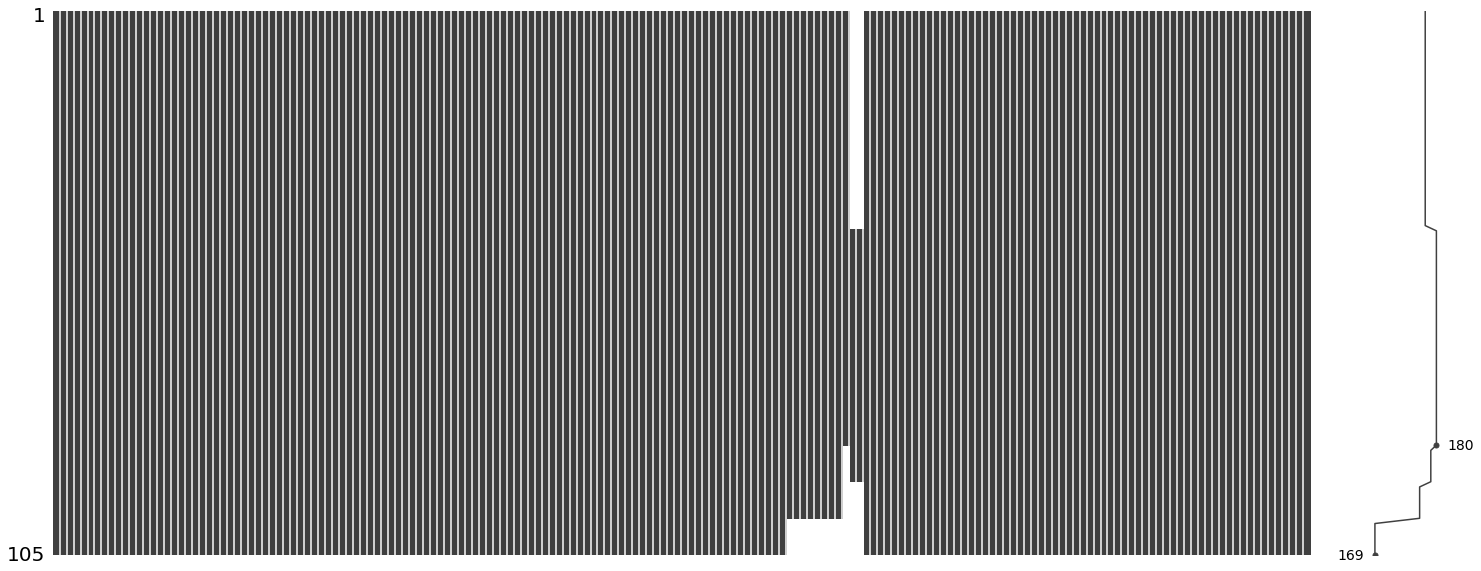

In [15]:
missingno.matrix(dataset_annual)

In [16]:
missing = describe_dataframe(dataset_annual, remove_zeros=True)
missing

,Column,Missing
0,M_Y_LT15,6.6667
1,M_Y15-64,6.6667
2,M_Y_GE65,6.6667
3,M_TOTAL,6.6667
4,F_Y_LT15,6.6667
5,F_Y15-64,6.6667
6,F_Y_GE65,6.6667
7,F_TOTAL,6.6667
8,MIO_EUR,20.0000
9,L_TOTAL,53.3333


In [17]:
dataset_annual.head(15)

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2009,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,0.448778,0.166486,-0.258939,-0.166486,0.444230,0.168831,-0.251853,-0.168831,0.051398,0.050371,0.036570,0.050371,20.019486,9.008837,14.514162,5.166060,9.054669,14.068100,14.964794,0.057874,0.608776,1.209346,1.830765,2.696421,4.831723,7.638723,8.397780,3.980535,21.635065,60.370251,119.752964,702.611191,562.026235,221.404250,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0.0,53.475540,2.926239,142.953571,0.0,1.0,22226.661302,3839.763398,39.0,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,4.675859,24.656049,121.820123,0,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,11723.0,44888.0,13557.0,70168.0,11361.0,44491.0,16024.0,71876.0,2098.63,NaN,NaN,1.509239,4.663823,7.643042,11.756611,0.338261,-0.236155,0.083967,-0.083967,0.329395,-0.239247,0.075621,-0.075621,0.053953,0.049460,0.053392,0.053392,1.509239,11.989997,23.159531,21.159051,0.396796,-0.238179,0.137084,-0.137084,0.392284,-0.232939,0.138621,-0.138621,0.047894,0.038397,0.046202,0.046202,1.509239,15.889353,24.851703,27.540381,0.448778,-0.258939,0.166486,-0.166486,0.444230,-0.251853,0.168831,-0.168831,0.051398,0.036570,0.050371,0.050371,1.509239,14.514162,24.851703,47.766417,0.448778,-0.258939,0.166486,-0.166486,0.444230,-0.251853,0.168831,-0.168831,0.051398,0.036570,0.050371,0.050371
1,2009,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,0.342978,0.096967,-0.227463,-0.096967,0.335772,0.101591,-0.216286,-0.101591,0.056806,0.063206,0.064433,0.063206,22.169983,9.485009,15.831436,7.145869,9.818153,15

In [18]:
dataset_annual.cases.sum()

936

In [19]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'MIO_EUR']

temp_df = dataset_annual[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['MIO_EUR']

dataset_annual[imputed_columns] = imputed_data[imputed_columns]

In [20]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'L_TOTAL']

temp_df = dataset_annual[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['L_TOTAL']

dataset_annual[imputed_columns] = imputed_data[imputed_columns]

In [21]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'UNL_TOTAL']

temp_df = dataset_annual[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['UNL_TOTAL']

dataset_annual[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

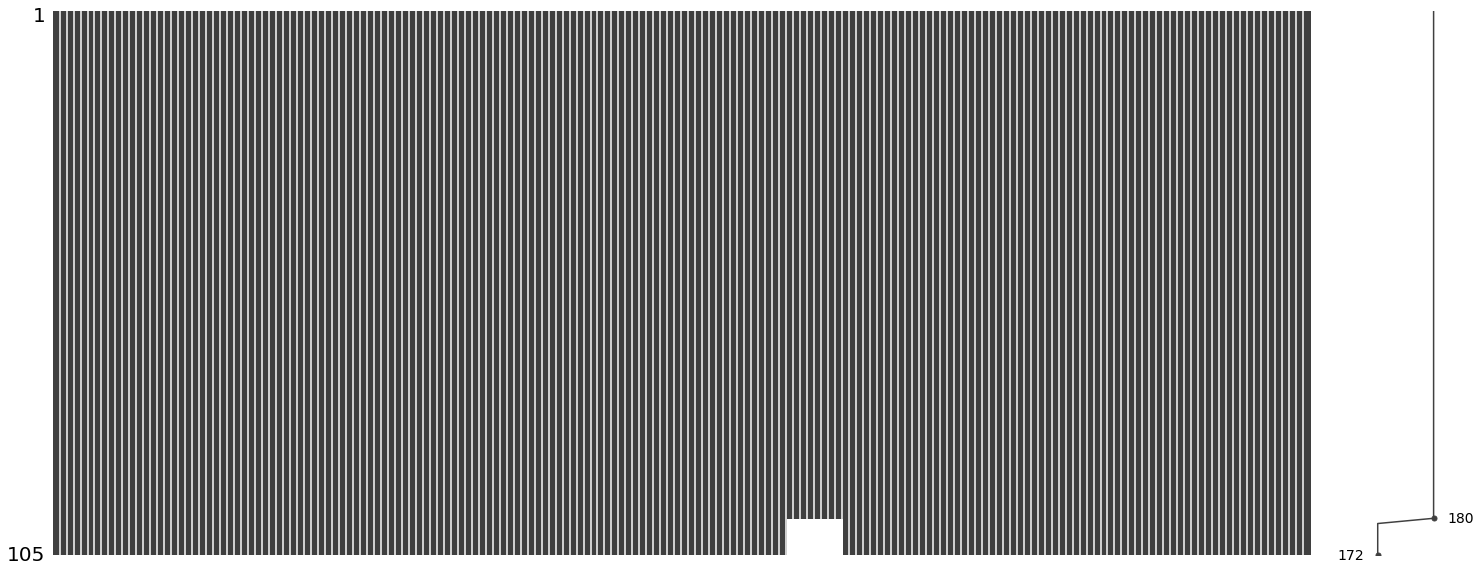

In [22]:
missingno.matrix(dataset_annual, label_rotation=90)

<AxesSubplot:>

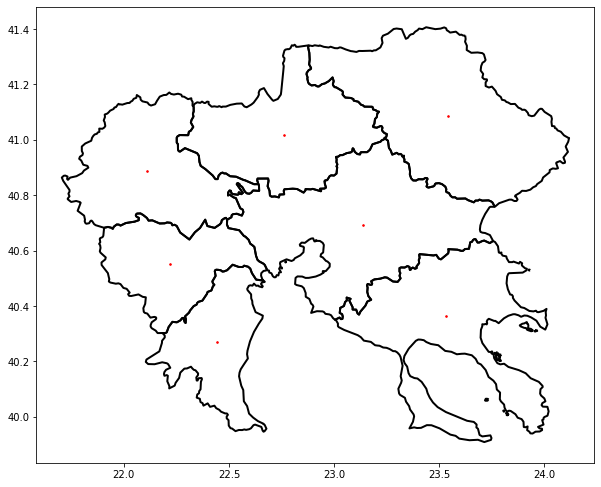

In [23]:
## Reading shapefiles from Greece

greece_nuts3_gdf = gpd.read_file(f"../../../../Europe NUTS - LAU/Greece/data/EL_Whole.shp",  encoding=enc)

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}']

nuts3_points = gpd.GeoDataFrame(dataset_annual[['NUTS3_NAME']], geometry=gpd.points_from_xy(dataset_annual.x, dataset_annual.y))

ax = nuts3_points.head(7).plot(markersize=2.5, figsize=(10, 10), color='red')
nuts3_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [24]:
data_q1 = []
data_q2 = []
data_q3 = []
data_q4 = []

for year in years[1:]:
    for region in nuts3_units:

        df_preceding = dataset_annual.loc[(dataset_annual['year'] == year-1) & (dataset_annual['NUTS3_NAME'] == region)]
        df_current = dataset_annual.loc[(dataset_annual['year'] == year) & (dataset_annual['NUTS3_NAME'] == region)]

        data_q1.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q1': df_current.min_temp_q1.iloc[0],
                        'mean_temp_q1': df_current.mean_temp_q1.iloc[0],
                        'max_temp_q1': df_current.max_temp_q1.iloc[0],
                        'prec_q1': df_current.prec_q1.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q1': df_current.ndvi_q1.iloc[0],
                        'ndwi_q1': df_current.ndwi_q1.iloc[0],
                        'ndmi_q1': df_current.ndmi_q1.iloc[0],
                        'ndbi_q1': df_current.ndbi_q1.iloc[0],
                        'ndvi_mean_q1': df_current.ndvi_mean_q1.iloc[0],
                        'ndwi_mean_q1': df_current.ndwi_mean_q1.iloc[0],
                        'ndmi_mean_q1': df_current.ndmi_mean_q1.iloc[0],
                        'ndbi_mean_q1': df_current.ndbi_mean_q1.iloc[0],
                        'ndvi_std_q1': df_current.ndvi_std_q1.iloc[0],
                        'ndwi_std_q1': df_current.ndwi_std_q1.iloc[0],
                        'ndmi_std_q1': df_current.ndmi_std_q1.iloc[0],
                        'ndbi_std_q1': df_current.ndbi_std_q1.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'distance_to_coast': df_preceding.distance_to_coast.iloc[0],
                        'distance_to_river': df_preceding.distance_to_river.iloc[0],
                        'slope_mean_1km': df_preceding.slope_mean_1km.iloc[0],
                        'aspect_mean_200m': df_preceding.aspect_mean_200m.iloc[0],
                        'elevation_mean_1km': df_preceding.elevation_mean_1km.iloc[0],
                        'hillshade_mean_1km': df_preceding.hillshade_mean_1km.iloc[0],
                        'fs_area_1km': df_preceding.fs_area_1km.iloc[0],
                        'flow_accu_200m': df_preceding.flow_accu_200m.iloc[0],
                        'lc_prop1': df_preceding.lc_prop1.iloc[0],
                        'lc_prop2': df_preceding.lc_prop2.iloc[0],                    
                        'lc_prop3': df_preceding.lc_prop3.iloc[0],
                        'lc_type1': df_preceding.lc_type1.iloc[0],
                        'lc_type2': df_preceding.lc_type2.iloc[0],
                        'lc_type3': df_preceding.lc_type3.iloc[0],
                        'lc_type4': df_preceding.lc_type4.iloc[0],
                        'lc_type5': df_preceding.lc_type5.iloc[0],
                        'lw': df_preceding.lw.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred_mean.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
        data_q2.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q2': df_current.min_temp_q2.iloc[0],
                        'mean_temp_q2': df_current.mean_temp_q2.iloc[0],
                        'max_temp_q2': df_current.max_temp_q2.iloc[0],
                        'prec_q2': df_current.prec_q2.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q2': df_current.ndvi_q2.iloc[0],
                        'ndwi_q2': df_current.ndwi_q2.iloc[0],
                        'ndmi_q2': df_current.ndmi_q2.iloc[0],
                        'ndbi_q2': df_current.ndbi_q2.iloc[0],
                        'ndvi_mean_q2': df_current.ndvi_mean_q2.iloc[0],
                        'ndwi_mean_q2': df_current.ndwi_mean_q2.iloc[0],
                        'ndmi_mean_q2': df_current.ndmi_mean_q2.iloc[0],
                        'ndbi_mean_q2': df_current.ndbi_mean_q2.iloc[0],
                        'ndvi_std_q2': df_current.ndvi_std_q2.iloc[0],
                        'ndwi_std_q2': df_current.ndwi_std_q2.iloc[0],
                        'ndmi_std_q2': df_current.ndmi_std_q2.iloc[0],
                        'ndbi_std_q2': df_current.ndbi_std_q2.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'distance_to_coast': df_preceding.distance_to_coast.iloc[0],
                        'distance_to_river': df_preceding.distance_to_river.iloc[0],
                        'slope_mean_1km': df_preceding.slope_mean_1km.iloc[0],
                        'aspect_mean_200m': df_preceding.aspect_mean_200m.iloc[0],
                        'elevation_mean_1km': df_preceding.elevation_mean_1km.iloc[0],
                        'hillshade_mean_1km': df_preceding.hillshade_mean_1km.iloc[0],
                        'fs_area_1km': df_preceding.fs_area_1km.iloc[0],
                        'flow_accu_200m': df_preceding.flow_accu_200m.iloc[0],
                        'lc_prop1': df_preceding.lc_prop1.iloc[0],
                        'lc_prop2': df_preceding.lc_prop2.iloc[0],                    
                        'lc_prop3': df_preceding.lc_prop3.iloc[0],
                        'lc_type1': df_preceding.lc_type1.iloc[0],
                        'lc_type2': df_preceding.lc_type2.iloc[0],
                        'lc_type3': df_preceding.lc_type3.iloc[0],
                        'lc_type4': df_preceding.lc_type4.iloc[0],
                        'lc_type5': df_preceding.lc_type5.iloc[0],
                        'lw': df_preceding.lw.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred_mean.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
        data_q3.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q3': df_current.min_temp_q3.iloc[0],
                        'mean_temp_q3': df_current.mean_temp_q3.iloc[0],
                        'max_temp_q3': df_current.max_temp_q3.iloc[0],
                        'prec_q3': df_current.prec_q3.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q3': df_current.ndvi_q3.iloc[0],
                        'ndwi_q3': df_current.ndwi_q3.iloc[0],
                        'ndmi_q3': df_current.ndmi_q3.iloc[0],
                        'ndbi_q3': df_current.ndbi_q3.iloc[0],
                        'ndvi_mean_q3': df_current.ndvi_mean_q3.iloc[0],
                        'ndwi_mean_q3': df_current.ndwi_mean_q3.iloc[0],
                        'ndmi_mean_q3': df_current.ndmi_mean_q3.iloc[0],
                        'ndbi_mean_q3': df_current.ndbi_mean_q3.iloc[0],
                        'ndvi_std_q3': df_current.ndvi_std_q3.iloc[0],
                        'ndwi_std_q3': df_current.ndwi_std_q3.iloc[0],
                        'ndmi_std_q3': df_current.ndmi_std_q3.iloc[0],
                        'ndbi_std_q3': df_current.ndbi_std_q3.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'distance_to_coast': df_preceding.distance_to_coast.iloc[0],
                        'distance_to_river': df_preceding.distance_to_river.iloc[0],
                        'slope_mean_1km': df_preceding.slope_mean_1km.iloc[0],
                        'aspect_mean_200m': df_preceding.aspect_mean_200m.iloc[0],
                        'elevation_mean_1km': df_preceding.elevation_mean_1km.iloc[0],
                        'hillshade_mean_1km': df_preceding.hillshade_mean_1km.iloc[0],
                        'fs_area_1km': df_preceding.fs_area_1km.iloc[0],
                        'flow_accu_200m': df_preceding.flow_accu_200m.iloc[0],
                        'lc_prop1': df_preceding.lc_prop1.iloc[0],
                        'lc_prop2': df_preceding.lc_prop2.iloc[0],                    
                        'lc_prop3': df_preceding.lc_prop3.iloc[0],
                        'lc_type1': df_preceding.lc_type1.iloc[0],
                        'lc_type2': df_preceding.lc_type2.iloc[0],
                        'lc_type3': df_preceding.lc_type3.iloc[0],
                        'lc_type4': df_preceding.lc_type4.iloc[0],
                        'lc_type5': df_preceding.lc_type5.iloc[0],
                        'lw': df_preceding.lw.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred_mean.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
        data_q4.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q4': df_current.min_temp_q4.iloc[0],
                        'mean_temp_q4': df_current.mean_temp_q4.iloc[0],
                        'max_temp_q4': df_current.max_temp_q4.iloc[0],
                        'prec_q4': df_current.prec_q4.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q4': df_current.ndvi_q4.iloc[0],
                        'ndwi_q4': df_current.ndwi_q4.iloc[0],
                        'ndmi_q4': df_current.ndmi_q4.iloc[0],
                        'ndbi_q4': df_current.ndbi_q4.iloc[0],
                        'ndvi_mean_q4': df_current.ndvi_mean_q4.iloc[0],
                        'ndwi_mean_q4': df_current.ndwi_mean_q4.iloc[0],
                        'ndmi_mean_q4': df_current.ndmi_mean_q4.iloc[0],
                        'ndbi_mean_q4': df_current.ndbi_mean_q4.iloc[0],
                        'ndvi_std_q4': df_current.ndvi_std_q4.iloc[0],
                        'ndwi_std_q4': df_current.ndwi_std_q4.iloc[0],
                        'ndmi_std_q4': df_current.ndmi_std_q4.iloc[0],
                        'ndbi_std_q4': df_current.ndbi_std_q4.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'distance_to_coast': df_preceding.distance_to_coast.iloc[0],
                        'distance_to_river': df_preceding.distance_to_river.iloc[0],
                        'slope_mean_1km': df_preceding.slope_mean_1km.iloc[0],
                        'aspect_mean_200m': df_preceding.aspect_mean_200m.iloc[0],
                        'elevation_mean_1km': df_preceding.elevation_mean_1km.iloc[0],
                        'hillshade_mean_1km': df_preceding.hillshade_mean_1km.iloc[0],
                        'fs_area_1km': df_preceding.fs_area_1km.iloc[0],
                        'flow_accu_200m': df_preceding.flow_accu_200m.iloc[0],
                        'lc_prop1': df_preceding.lc_prop1.iloc[0],
                        'lc_prop2': df_preceding.lc_prop2.iloc[0],                    
                        'lc_prop3': df_preceding.lc_prop3.iloc[0],
                        'lc_type1': df_preceding.lc_type1.iloc[0],
                        'lc_type2': df_preceding.lc_type2.iloc[0],
                        'lc_type3': df_preceding.lc_type3.iloc[0],
                        'lc_type4': df_preceding.lc_type4.iloc[0],
                        'lc_type5': df_preceding.lc_type5.iloc[0],
                        'lw': df_preceding.lw.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred_mean.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
df_q1 = pd.DataFrame(data_q1)
df_q2 = pd.DataFrame(data_q2)   
df_q3 = pd.DataFrame(data_q3)   
df_q4 = pd.DataFrame(data_q4)   

In [25]:
df_q1

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,4.112363,6.145260,9.853286,16.614061,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,0.299580,-0.145977,0.137769,-0.137769,0.299260,-0.145249,0.138721,-0.138721,0.042502,0.043421,0.045998,0.045998,70168.0,11723.0,44888.0,13557.0,71876.0,11361.0,44491.0,16024.0,2098.630,5025.2,5265.4,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,221.404250,49
1,2010,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,4.821270,7.033430,10.522830,13.678385,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,0.246127,0.027913,0.235072,-0.235072,0.241160,0.029131,0.232349,-0.232349,0.048505,0.077228,0.061491,0.061491,542053.0,87281.0,374669.0,80103.0,591836.0,83839.0,403005.0,104992.0,21520.330,9804.6,10058.8,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,190.026906,81
2,2010,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,3.783619,6.595166,10.528780,11.666570,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,0.196208,0.181480,0.357342,-0.357342,0.198035,0.166190,0.342679,-0.342679,0.031112,0.058279,0.034329,0.034329,39881.0,5916.0,24162.0,9803.0,40875.0,5598.0,23417.0,11860.0,1169.860,5809.2,5920.4,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,184.019550,23
3,2010,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,3.685077,5.968107,9.954364,15.621303,14.708333,19.916667,43.297101,849.186331,38.0,-8.0,46.0,6.000000,24.500000,25.166667,4.666667,1512.0,287.0,44.0,60.410595,683.0,204.0,288.0,579.0,0.334891,-0.232117,0.091553,-0.091553,0.328280,-0.228668,0.090159,-0.090159,0.047250,0.067269,0.062925,0.062925,70357.0,11214.0,44608.0,14535.0,71745.0,11089.0,43192.0,17464.0,2022.780,5025.2,5265.4,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,31.0,36.0,30.0,12.0,9.0,4.0,4.0,4.0,2.0,209.445491,57
4,2010,EL52,κεντρικη μακεδονια,EL525,πιερια,22.442423,40.269959,5.759019,7.550798,10.821806,15.959433,15.500000,19.500000,43.333333,837.745893,40.0,-5.0,45.0,7.333333,25.166667,26.000000,5.666667,1275.0,275.0,51.0,66.546526,571.0,176.0,199.0,521.0,0.350204,-0.261349,0.082357,-0.082357,0.333338,-0.202925,0.110173,-0.110173,0.041642,0.051140,0.044747,0.044747,61913.0,10377.0,39695.0,11841.0,64447.0,10120.0,40015.0,14312.0,1815.790,5025.2,5265.4,10529.200600,979.257510,11.822222,148.678278,321.171339,171.108861,0.000000,14.790525,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,269.651285,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,2023,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,5.833525,7.744332,10.805813,1.767312,16.7

In [26]:
df_q2

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,4.112363,12.747725,22.888179,26.296789,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,0.459282,-0.266305,0.174979,-0.174979,0.459757,-0.265555,0.175139,-0.175139,0.050956,0.037116,0.048983,0.048983,70168.0,11723.0,44888.0,13557.0,71876.0,11361.0,44491.0,16024.0,2098.630,5025.2,5265.4,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,221.404250,49
1,2010,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,4.821270,13.519503,23.528776,22.849015,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,0.337459,-0.121393,0.190315,-0.190315,0.329387,-0.116124,0.187586,-0.187586,0.052154,0.060136,0.056163,0.056163,542053.0,87281.0,374669.0,80103.0,591836.0,83839.0,403005.0,104992.0,21520.330,9804.6,10058.8,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,190.026906,81
2,2010,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,3.783619,13.320823,24.154946,21.458399,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,0.323978,-0.068251,0.241842,-0.241842,0.326785,-0.069790,0.241337,-0.241337,0.041625,0.044521,0.041747,0.041747,39881.0,5916.0,24162.0,9803.0,40875.0,5598.0,23417.0,11860.0,1169.860,5809.2,5920.4,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,184.019550,23
3,2010,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,3.685077,12.450188,22.560095,26.291151,14.708333,19.916667,43.297101,849.186331,38.0,-8.0,46.0,6.000000,24.500000,25.166667,4.666667,1512.0,287.0,44.0,60.410595,683.0,204.0,288.0,579.0,0.459519,-0.284858,0.155265,-0.155265,0.456875,-0.277248,0.160891,-0.160891,0.051192,0.051079,0.054637,0.054637,70357.0,11214.0,44608.0,14535.0,71745.0,11089.0,43192.0,17464.0,2022.780,5025.2,5265.4,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,31.0,36.0,30.0,12.0,9.0,4.0,4.0,4.0,2.0,209.445491,57
4,2010,EL52,κεντρικη μακεδονια,EL525,πιερια,22.442423,40.269959,5.759019,13.316376,22.800193,24.779606,15.500000,19.500000,43.333333,837.745893,40.0,-5.0,45.0,7.333333,25.166667,26.000000,5.666667,1275.0,275.0,51.0,66.546526,571.0,176.0,199.0,521.0,0.451906,-0.290794,0.147729,-0.147729,0.447021,-0.261584,0.164782,-0.164782,0.057783,0.038783,0.052734,0.052734,61913.0,10377.0,39695.0,11841.0,64447.0,10120.0,40015.0,14312.0,1815.790,5025.2,5265.4,10529.200600,979.257510,11.822222,148.678278,321.171339,171.108861,0.000000,14.790525,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,269.651285,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,2023,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,5.833525,12.616750,22.087843,8

In [27]:
df_q3

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,4.112363,16.367764,26.181547,33.537056,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,0.504286,-0.299304,0.188064,-0.188064,0.506798,-0.297162,0.191052,-0.191052,0.056979,0.034147,0.053448,0.053448,70168.0,11723.0,44888.0,13557.0,71876.0,11361.0,44491.0,16024.0,2098.630,5025.2,5265.4,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,221.404250,49
1,2010,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,4.821270,17.782211,29.032072,28.047625,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,0.348719,-0.178156,0.152549,-0.152549,0.341001,-0.169125,0.153318,-0.153318,0.055008,0.058418,0.057519,0.057519,542053.0,87281.0,374669.0,80103.0,591836.0,83839.0,403005.0,104992.0,21520.330,9804.6,10058.8,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,190.026906,81
2,2010,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,3.783619,17.692167,29.346329,28.019172,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,0.349616,-0.161805,0.179398,-0.179398,0.349630,-0.161106,0.179264,-0.179264,0.045894,0.043199,0.045652,0.045652,39881.0,5916.0,24162.0,9803.0,40875.0,5598.0,23417.0,11860.0,1169.860,5809.2,5920.4,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,184.019550,23
3,2010,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,3.685077,16.350589,27.033842,33.702197,14.708333,19.916667,43.297101,849.186331,38.0,-8.0,46.0,6.000000,24.500000,25.166667,4.666667,1512.0,287.0,44.0,60.410595,683.0,204.0,288.0,579.0,0.512251,-0.308684,0.182513,-0.182513,0.507571,-0.301060,0.186153,-0.186153,0.052474,0.045819,0.053983,0.053983,70357.0,11214.0,44608.0,14535.0,71745.0,11089.0,43192.0,17464.0,2022.780,5025.2,5265.4,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,31.0,36.0,30.0,12.0,9.0,4.0,4.0,4.0,2.0,209.445491,57
4,2010,EL52,κεντρικη μακεδονια,EL525,πιερια,22.442423,40.269959,5.759019,17.300494,27.920760,32.606561,15.500000,19.500000,43.333333,837.745893,40.0,-5.0,45.0,7.333333,25.166667,26.000000,5.666667,1275.0,275.0,51.0,66.546526,571.0,176.0,199.0,521.0,0.459825,-0.308067,0.140728,-0.140728,0.455635,-0.288171,0.151793,-0.151793,0.062898,0.037329,0.056997,0.056997,61913.0,10377.0,39695.0,11841.0,64447.0,10120.0,40015.0,14312.0,1815.790,5025.2,5265.4,10529.200600,979.257510,11.822222,148.678278,321.171339,171.108861,0.000000,14.790525,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,269.651285,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,2023,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,5.833525,17.487855,28.439276,1

In [28]:
df_q4

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,4.001422,14.592870,26.181547,52.583673,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,0.465654,-0.245091,0.194951,-0.194951,0.465870,-0.242407,0.197104,-0.197104,0.054881,0.040630,0.053100,0.053100,70168.0,11723.0,44888.0,13557.0,71876.0,11361.0,44491.0,16024.0,2098.630,5025.2,5265.4,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,221.404250,49
1,2010,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,4.821270,16.026155,29.032072,44.681150,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,0.339957,-0.168468,0.149822,-0.149822,0.331702,-0.160191,0.149799,-0.149799,0.056435,0.061077,0.058687,0.058687,542053.0,87281.0,374669.0,80103.0,591836.0,83839.0,403005.0,104992.0,21520.330,9804.6,10058.8,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,190.026906,81
2,2010,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,3.783619,15.756968,29.346329,46.981894,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,0.335118,-0.172135,0.151585,-0.151585,0.333946,-0.168146,0.153800,-0.153800,0.046777,0.043620,0.046711,0.046711,39881.0,5916.0,24162.0,9803.0,40875.0,5598.0,23417.0,11860.0,1169.860,5809.2,5920.4,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,184.019550,23
3,2010,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,3.649571,14.561725,27.033842,54.202848,14.708333,19.916667,43.297101,849.186331,38.0,-8.0,46.0,6.000000,24.500000,25.166667,4.666667,1512.0,287.0,44.0,60.410595,683.0,204.0,288.0,579.0,0.476241,-0.266093,0.184031,-0.184031,0.472259,-0.257275,0.189336,-0.189336,0.051712,0.050754,0.054227,0.054227,70357.0,11214.0,44608.0,14535.0,71745.0,11089.0,43192.0,17464.0,2022.780,5025.2,5265.4,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,31.0,36.0,30.0,12.0,9.0,4.0,4.0,4.0,2.0,209.445491,57
4,2010,EL52,κεντρικη μακεδονια,EL525,πιερια,22.442423,40.269959,5.661907,15.649611,27.920760,48.945308,15.500000,19.500000,43.333333,837.745893,40.0,-5.0,45.0,7.333333,25.166667,26.000000,5.666667,1275.0,275.0,51.0,66.546526,571.0,176.0,199.0,521.0,0.430316,-0.259129,0.152485,-0.152485,0.422977,-0.239422,0.160766,-0.160766,0.062403,0.046591,0.059236,0.059236,61913.0,10377.0,39695.0,11841.0,64447.0,10120.0,40015.0,14312.0,1815.790,5025.2,5265.4,10529.200600,979.257510,11.822222,148.678278,321.171339,171.108861,0.000000,14.790525,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,269.651285,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,2023,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,5.833525,16.260677,28.439276,1

In [29]:
print(df_q1.WNV_cases.sum())
print(df_q2.WNV_cases.sum())
print(df_q3.WNV_cases.sum())
print(df_q4.WNV_cases.sum())

936
936
936
936


In [30]:
print(df_q1.WNV_cases.sum())
print(df_q2.WNV_cases.sum())
print(df_q3.WNV_cases.sum())
print(df_q4.WNV_cases.sum())

936
936
936
936


In [31]:
df_q1

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,4.112363,6.145260,9.853286,16.614061,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,0.299580,-0.145977,0.137769,-0.137769,0.299260,-0.145249,0.138721,-0.138721,0.042502,0.043421,0.045998,0.045998,70168.0,11723.0,44888.0,13557.0,71876.0,11361.0,44491.0,16024.0,2098.630,5025.2,5265.4,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,221.404250,49
1,2010,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,4.821270,7.033430,10.522830,13.678385,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,0.246127,0.027913,0.235072,-0.235072,0.241160,0.029131,0.232349,-0.232349,0.048505,0.077228,0.061491,0.061491,542053.0,87281.0,374669.0,80103.0,591836.0,83839.0,403005.0,104992.0,21520.330,9804.6,10058.8,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,190.026906,81
2,2010,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,3.783619,6.595166,10.528780,11.666570,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,0.196208,0.181480,0.357342,-0.357342,0.198035,0.166190,0.342679,-0.342679,0.031112,0.058279,0.034329,0.034329,39881.0,5916.0,24162.0,9803.0,40875.0,5598.0,23417.0,11860.0,1169.860,5809.2,5920.4,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,184.019550,23
3,2010,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,3.685077,5.968107,9.954364,15.621303,14.708333,19.916667,43.297101,849.186331,38.0,-8.0,46.0,6.000000,24.500000,25.166667,4.666667,1512.0,287.0,44.0,60.410595,683.0,204.0,288.0,579.0,0.334891,-0.232117,0.091553,-0.091553,0.328280,-0.228668,0.090159,-0.090159,0.047250,0.067269,0.062925,0.062925,70357.0,11214.0,44608.0,14535.0,71745.0,11089.0,43192.0,17464.0,2022.780,5025.2,5265.4,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,31.0,36.0,30.0,12.0,9.0,4.0,4.0,4.0,2.0,209.445491,57
4,2010,EL52,κεντρικη μακεδονια,EL525,πιερια,22.442423,40.269959,5.759019,7.550798,10.821806,15.959433,15.500000,19.500000,43.333333,837.745893,40.0,-5.0,45.0,7.333333,25.166667,26.000000,5.666667,1275.0,275.0,51.0,66.546526,571.0,176.0,199.0,521.0,0.350204,-0.261349,0.082357,-0.082357,0.333338,-0.202925,0.110173,-0.110173,0.041642,0.051140,0.044747,0.044747,61913.0,10377.0,39695.0,11841.0,64447.0,10120.0,40015.0,14312.0,1815.790,5025.2,5265.4,10529.200600,979.257510,11.822222,148.678278,321.171339,171.108861,0.000000,14.790525,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,269.651285,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,2023,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,5.833525,7.744332,10.805813,1.767312,16.7

In [32]:
df_q2

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,4.112363,12.747725,22.888179,26.296789,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,0.459282,-0.266305,0.174979,-0.174979,0.459757,-0.265555,0.175139,-0.175139,0.050956,0.037116,0.048983,0.048983,70168.0,11723.0,44888.0,13557.0,71876.0,11361.0,44491.0,16024.0,2098.630,5025.2,5265.4,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,221.404250,49
1,2010,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,4.821270,13.519503,23.528776,22.849015,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,0.337459,-0.121393,0.190315,-0.190315,0.329387,-0.116124,0.187586,-0.187586,0.052154,0.060136,0.056163,0.056163,542053.0,87281.0,374669.0,80103.0,591836.0,83839.0,403005.0,104992.0,21520.330,9804.6,10058.8,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,190.026906,81
2,2010,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,3.783619,13.320823,24.154946,21.458399,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,0.323978,-0.068251,0.241842,-0.241842,0.326785,-0.069790,0.241337,-0.241337,0.041625,0.044521,0.041747,0.041747,39881.0,5916.0,24162.0,9803.0,40875.0,5598.0,23417.0,11860.0,1169.860,5809.2,5920.4,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,184.019550,23
3,2010,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,3.685077,12.450188,22.560095,26.291151,14.708333,19.916667,43.297101,849.186331,38.0,-8.0,46.0,6.000000,24.500000,25.166667,4.666667,1512.0,287.0,44.0,60.410595,683.0,204.0,288.0,579.0,0.459519,-0.284858,0.155265,-0.155265,0.456875,-0.277248,0.160891,-0.160891,0.051192,0.051079,0.054637,0.054637,70357.0,11214.0,44608.0,14535.0,71745.0,11089.0,43192.0,17464.0,2022.780,5025.2,5265.4,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,31.0,36.0,30.0,12.0,9.0,4.0,4.0,4.0,2.0,209.445491,57
4,2010,EL52,κεντρικη μακεδονια,EL525,πιερια,22.442423,40.269959,5.759019,13.316376,22.800193,24.779606,15.500000,19.500000,43.333333,837.745893,40.0,-5.0,45.0,7.333333,25.166667,26.000000,5.666667,1275.0,275.0,51.0,66.546526,571.0,176.0,199.0,521.0,0.451906,-0.290794,0.147729,-0.147729,0.447021,-0.261584,0.164782,-0.164782,0.057783,0.038783,0.052734,0.052734,61913.0,10377.0,39695.0,11841.0,64447.0,10120.0,40015.0,14312.0,1815.790,5025.2,5265.4,10529.200600,979.257510,11.822222,148.678278,321.171339,171.108861,0.000000,14.790525,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,269.651285,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,2023,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,5.833525,12.616750,22.087843,8

In [33]:
df_q3

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,4.112363,16.367764,26.181547,33.537056,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,0.504286,-0.299304,0.188064,-0.188064,0.506798,-0.297162,0.191052,-0.191052,0.056979,0.034147,0.053448,0.053448,70168.0,11723.0,44888.0,13557.0,71876.0,11361.0,44491.0,16024.0,2098.630,5025.2,5265.4,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,221.404250,49
1,2010,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,4.821270,17.782211,29.032072,28.047625,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,0.348719,-0.178156,0.152549,-0.152549,0.341001,-0.169125,0.153318,-0.153318,0.055008,0.058418,0.057519,0.057519,542053.0,87281.0,374669.0,80103.0,591836.0,83839.0,403005.0,104992.0,21520.330,9804.6,10058.8,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,190.026906,81
2,2010,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,3.783619,17.692167,29.346329,28.019172,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,0.349616,-0.161805,0.179398,-0.179398,0.349630,-0.161106,0.179264,-0.179264,0.045894,0.043199,0.045652,0.045652,39881.0,5916.0,24162.0,9803.0,40875.0,5598.0,23417.0,11860.0,1169.860,5809.2,5920.4,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,184.019550,23
3,2010,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,3.685077,16.350589,27.033842,33.702197,14.708333,19.916667,43.297101,849.186331,38.0,-8.0,46.0,6.000000,24.500000,25.166667,4.666667,1512.0,287.0,44.0,60.410595,683.0,204.0,288.0,579.0,0.512251,-0.308684,0.182513,-0.182513,0.507571,-0.301060,0.186153,-0.186153,0.052474,0.045819,0.053983,0.053983,70357.0,11214.0,44608.0,14535.0,71745.0,11089.0,43192.0,17464.0,2022.780,5025.2,5265.4,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,31.0,36.0,30.0,12.0,9.0,4.0,4.0,4.0,2.0,209.445491,57
4,2010,EL52,κεντρικη μακεδονια,EL525,πιερια,22.442423,40.269959,5.759019,17.300494,27.920760,32.606561,15.500000,19.500000,43.333333,837.745893,40.0,-5.0,45.0,7.333333,25.166667,26.000000,5.666667,1275.0,275.0,51.0,66.546526,571.0,176.0,199.0,521.0,0.459825,-0.308067,0.140728,-0.140728,0.455635,-0.288171,0.151793,-0.151793,0.062898,0.037329,0.056997,0.056997,61913.0,10377.0,39695.0,11841.0,64447.0,10120.0,40015.0,14312.0,1815.790,5025.2,5265.4,10529.200600,979.257510,11.822222,148.678278,321.171339,171.108861,0.000000,14.790525,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,269.651285,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,2023,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,5.833525,17.487855,28.439276,1

In [34]:
df_q4

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,4.001422,14.592870,26.181547,52.583673,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,0.465654,-0.245091,0.194951,-0.194951,0.465870,-0.242407,0.197104,-0.197104,0.054881,0.040630,0.053100,0.053100,70168.0,11723.0,44888.0,13557.0,71876.0,11361.0,44491.0,16024.0,2098.630,5025.2,5265.4,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,221.404250,49
1,2010,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,4.821270,16.026155,29.032072,44.681150,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,0.339957,-0.168468,0.149822,-0.149822,0.331702,-0.160191,0.149799,-0.149799,0.056435,0.061077,0.058687,0.058687,542053.0,87281.0,374669.0,80103.0,591836.0,83839.0,403005.0,104992.0,21520.330,9804.6,10058.8,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,190.026906,81
2,2010,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,3.783619,15.756968,29.346329,46.981894,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,0.335118,-0.172135,0.151585,-0.151585,0.333946,-0.168146,0.153800,-0.153800,0.046777,0.043620,0.046711,0.046711,39881.0,5916.0,24162.0,9803.0,40875.0,5598.0,23417.0,11860.0,1169.860,5809.2,5920.4,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,184.019550,23
3,2010,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,3.649571,14.561725,27.033842,54.202848,14.708333,19.916667,43.297101,849.186331,38.0,-8.0,46.0,6.000000,24.500000,25.166667,4.666667,1512.0,287.0,44.0,60.410595,683.0,204.0,288.0,579.0,0.476241,-0.266093,0.184031,-0.184031,0.472259,-0.257275,0.189336,-0.189336,0.051712,0.050754,0.054227,0.054227,70357.0,11214.0,44608.0,14535.0,71745.0,11089.0,43192.0,17464.0,2022.780,5025.2,5265.4,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,31.0,36.0,30.0,12.0,9.0,4.0,4.0,4.0,2.0,209.445491,57
4,2010,EL52,κεντρικη μακεδονια,EL525,πιερια,22.442423,40.269959,5.661907,15.649611,27.920760,48.945308,15.500000,19.500000,43.333333,837.745893,40.0,-5.0,45.0,7.333333,25.166667,26.000000,5.666667,1275.0,275.0,51.0,66.546526,571.0,176.0,199.0,521.0,0.430316,-0.259129,0.152485,-0.152485,0.422977,-0.239422,0.160766,-0.160766,0.062403,0.046591,0.059236,0.059236,61913.0,10377.0,39695.0,11841.0,64447.0,10120.0,40015.0,14312.0,1815.790,5025.2,5265.4,10529.200600,979.257510,11.822222,148.678278,321.171339,171.108861,0.000000,14.790525,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,269.651285,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,2023,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,5.833525,16.260677,28.439276,1

In [35]:
df_q1.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q1_2010_2023.csv", encoding = enc, index = False)
df_q2.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q2_2010_2023.csv", encoding = enc, index = False)
df_q3.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q3_2010_2023.csv", encoding = enc, index = False)
df_q4.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q4_2010_2023.csv", encoding = enc, index = False)